In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [44]:
heart_df = pd.read_csv("../data/raw/heart.csv")
diabetes_df = pd.read_csv("../data/raw/diabetes.csv")
cancer_df = pd.read_csv("../data/raw/breast_cancer.csv")

print("Datasets loaded successfully!")

Datasets loaded successfully!


In [24]:
datasets = {
    "Heart": heart_df,
    "Diabetes": diabetes_df,
    "Cancer": cancer_df
}

for name, df in datasets.items():
    print("\n====================")
    print(name)
    print("====================")
    print(df.info())
    print(df.isnull().sum())


Heart
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: i

In [25]:
# Handling missing values (if any)

heart_df.fillna(heart_df.median(numeric_only=True), inplace=True)

In [26]:
# Diabetes dataset cleaning

cols = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]

for col in cols:
    diabetes_df[col] = diabetes_df[col].replace(0, np.nan)
    diabetes_df[col].fillna(diabetes_df[col].median(), inplace=True)

/var/folders/5b/5zqbkshd1s3fzhwrgxhly9gh0000gn/T/ipykernel_2257/750350509.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  diabetes_df[col].fillna(diabetes_df[col].median(), inplace=True)
/var/folders/5b/5zqbkshd1s3fzhwrgxhly9gh0000gn/T/ipykernel_2257/750350509.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting

In [27]:
#Cancer dataset cleaning

cancer_df.fillna(cancer_df.median(numeric_only=True), inplace=True)

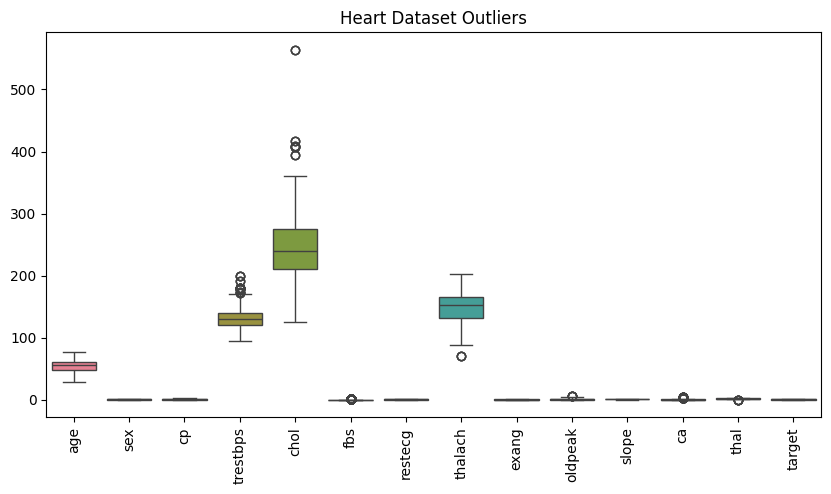

In [28]:
#Outlier Detection 

plt.figure(figsize=(10,5))
sns.boxplot(data=heart_df)
plt.xticks(rotation=90)
plt.title("Heart Dataset Outliers")
plt.show()

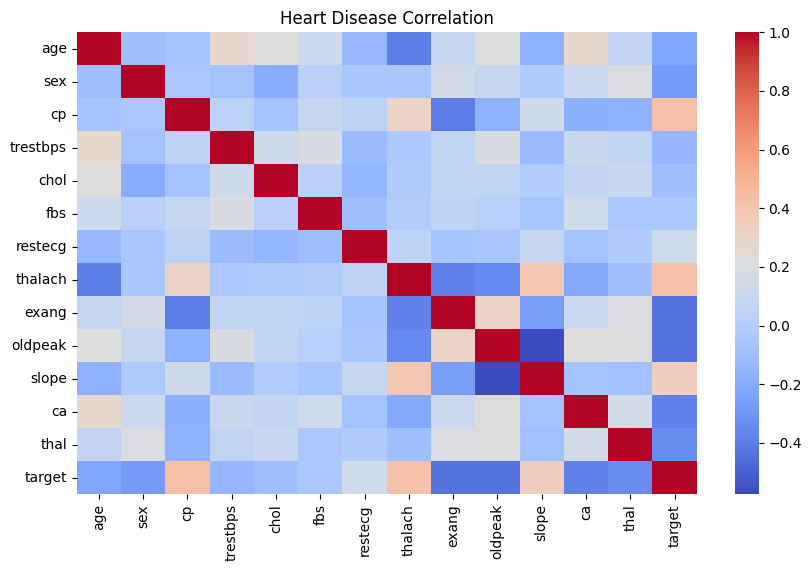

In [29]:
#Correlation Analysis

#Heart Disease

plt.figure(figsize=(10,6))
sns.heatmap(heart_df.corr(), cmap="coolwarm")
plt.title("Heart Disease Correlation")
plt.show()


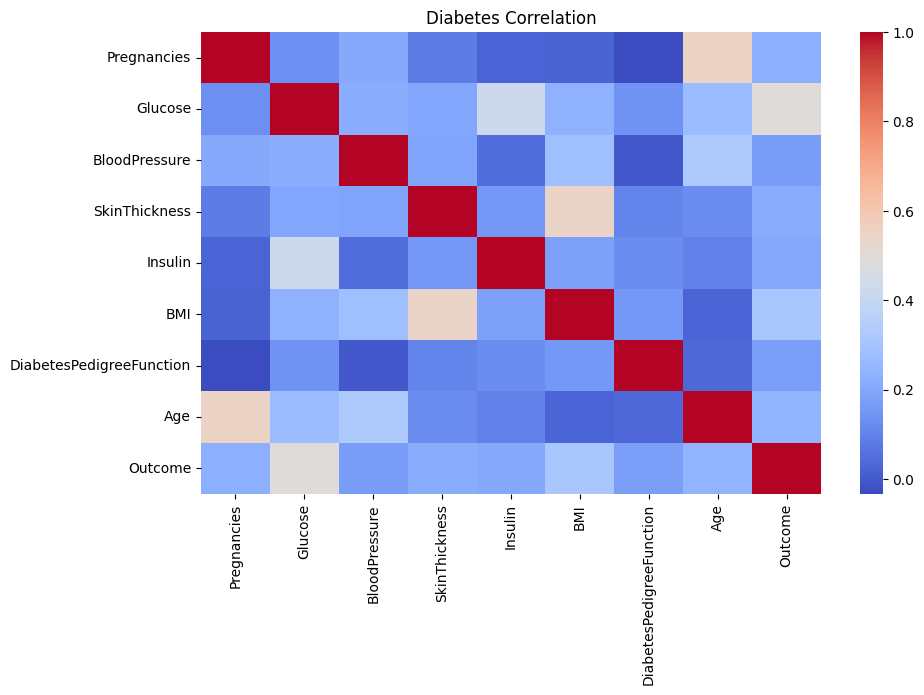

In [30]:
#Dianetes

plt.figure(figsize=(10,6))
sns.heatmap(diabetes_df.corr(), cmap="coolwarm")
plt.title("Diabetes Correlation")
plt.show()

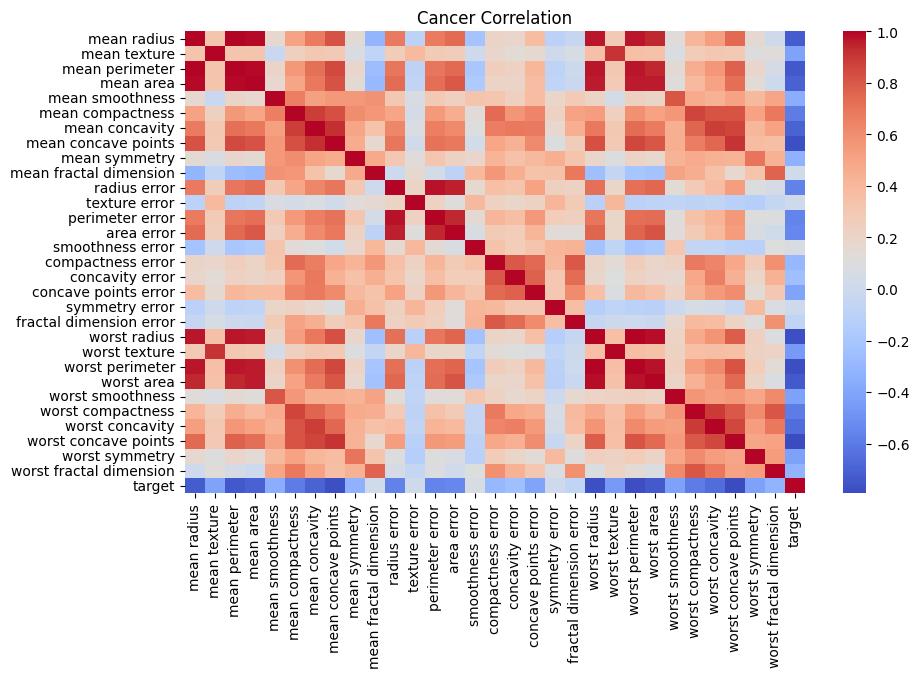

In [31]:
#Cancer
plt.figure(figsize=(10,6))
sns.heatmap(cancer_df.corr(), cmap="coolwarm")
plt.title("Cancer Correlation")
plt.show()

Feature and Target Split

In [32]:
#Heart Disease

X_heart = heart_df.drop("target", axis=1)
y_heart = heart_df["target"]

In [33]:
# Diabetes

X_diabetes = diabetes_df.drop("Outcome", axis=1)
y_diabetes = diabetes_df["Outcome"]

In [34]:
#Cancer

X_cancer = cancer_df.drop("target", axis=1)
y_cancer = cancer_df["target"]

Train Test Split

In [35]:
Xh_train, Xh_test, yh_train, yh_test = train_test_split(
    X_heart, y_heart, test_size=0.2, random_state=42
)

Xd_train, Xd_test, yd_train, yd_test = train_test_split(
    X_diabetes, y_diabetes, test_size=0.2, random_state=42
)

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42
)

Feature Scaling

In [36]:
scaler_heart = StandardScaler()
scaler_diabetes = StandardScaler()
scaler_cancer = StandardScaler()

Applying Scaling

In [37]:
Xh_train = scaler_heart.fit_transform(Xh_train)
Xh_test = scaler_heart.transform(Xh_test)

Xd_train = scaler_diabetes.fit_transform(Xd_train)
Xd_test = scaler_diabetes.transform(Xd_test)

Xc_train = scaler_cancer.fit_transform(Xc_train)
Xc_test = scaler_cancer.transform(Xc_test)

Save Processed Data

In [38]:
import os

os.makedirs("../data/processed", exist_ok=True)

np.save("../data/processed/Xh_train.npy", Xh_train)
np.save("../data/processed/Xh_test.npy", Xh_test)
np.save("../data/processed/yh_train.npy", yh_train)
np.save("../data/processed/yh_test.npy", yh_test)

np.save("../data/processed/Xd_train.npy", Xd_train)
np.save("../data/processed/Xd_test.npy", Xd_test)
np.save("../data/processed/yd_train.npy", yd_train)
np.save("../data/processed/yd_test.npy", yd_test)

np.save("../data/processed/Xc_train.npy", Xc_train)
np.save("../data/processed/Xc_test.npy", Xc_test)
np.save("../data/processed/yc_train.npy", yc_train)
np.save("../data/processed/yc_test.npy", yc_test)

print("All processed datasets saved successfully!")

All processed datasets saved successfully!
